### Getting Data from API

#### Retrive and Store Data

In [18]:
import urllib.request
import json

data = []
for i in range(1,101):
    string_i = str(i)
    url=('https://jsonplaceholder.typicode.com/posts/' + string_i)
    response = urllib.request.urlopen(url)
    data.append(json.loads(response.read().decode('UTF-8')))

file_path = 'data_from_api/data.json'
with open(file_path, 'w', encoding='UTF-8') as file:
    json.dump(data, file)

#### Open Data

In [19]:
with open(file_path, 'r', encoding='UTF-8') as openfile:
    json_object = json.load(openfile)
print(json_object) 

[{'userId': 1, 'id': 1, 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}, {'userId': 1, 'id': 2, 'title': 'qui est esse', 'body': 'est rerum tempore vitae\nsequi sint nihil reprehenderit dolor beatae ea dolores neque\nfugiat blanditiis voluptate porro vel nihil molestiae ut reiciendis\nqui aperiam non debitis possimus qui neque nisi nulla'}, {'userId': 1, 'id': 3, 'title': 'ea molestias quasi exercitationem repellat qui ipsa sit aut', 'body': 'et iusto sed quo iure\nvoluptatem occaecati omnis eligendi aut ad\nvoluptatem doloribus vel accusantium quis pariatur\nmolestiae porro eius odio et labore et velit aut'}, {'userId': 1, 'id': 4, 'title': 'eum et est occaecati', 'body': 'ullam et saepe reiciendis voluptatem adipisci\nsit amet autem assumenda provident rerum culpa\nquis hic c

#### Now we can play with data

In [20]:
import pandas as pd

df = pd.read_json(file_path)
df.head()

,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...


### Getting Data from Web Scraping

#### Parse the HTML Page

In [21]:
import requests
from bs4 import BeautifulSoup

url = 'https://www.kdnuggets.com/news/index.html'
response = requests.get(url)

# Parse the HTML code using BeautifulSoup
soup = BeautifulSoup(response.content, 'html.parser')
print(soup.prettify())

<!DOCTYPE html>
<html lang="en-US" xmlns="https://www.w3.org/1999/xhtml">
 <head profile="https://gmpg.org/xfn/11">
  <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
  <meta content="width=device-width, initial-scale=1" name="viewport"/>
  <meta content="ca-pub-3739583407805336" name="google-adsense-account"/>
  <!--<meta name="robots" content="max-image-preview:large">-->
  <title>
   News - KDnuggets
  </title>
  <link as="image" fetchpriority="high" href="https://www.kdnuggets.com/wp-content/themes/kdn17/images/logo.svg" rel="preload"/>
  <link as="image" fetchpriority="high" href="https://www.kdnuggets.com/wp-content/themes/kdn17/images/menu.svg" rel="preload"/>
  <link as="image" fetchpriority="high" href="https://www.kdnuggets.com/wp-content/themes/kdn17/images/search.svg" rel="preload"/>
  <link as="font" crossorigin="" href="https://www.kdnuggets.com/wp-content/cache/perfmatters/www.kdnuggets.com/fonts/memvYaGs126MiZpBA-UvWbX2vVnXBbObj2OVTS-mu0SC55I.woff2" 

#### Retrive Data and Store It into a Dataframe

In [22]:
import pandas as pd

# Extract the relevant information from the HTML code
latest_posts = []
for row in soup.select('table.thb ul li.li-has-thumb '):
    title = row.find('a').get_text()
    description = row.find('font').get_text().strip()
    author = row.find('div', class_='author-link').find('a').get_text()
    latest_posts.append([title, description, author])

# Store the information in a pandas dataframe
df = pd.DataFrame(latest_posts, columns=['Title', 'Description', 'Author'])

df

,Title,Description,Author
0,Why I Quit My 6 Figure Side Hustle for a Full-...,Here's why you should not quit your full-time ...,Natassha Selvaraj
1,Exploring Metaclasses in Python: Unleashing th...,Understand how useful in working with the meta...,Cornellius Yudha Wijaya
2,Debunking 5 Myths About Cloud Computing for Sm...,,KDnuggets
3,The Algorithmic X-Men,"We've assembled our team of Algorithmic X-Men,...",Matthew Mayo
4,Python for Data Science (Free 7-Day Mini-Course),Want to learn Python for data science? Start t...,Bala Priya C
...,...,...,...
70,7 Surprisingly Useful Python Scripts You’ll Us...,Not using Python for daily life? You're missin...,Kanwal Mehreen
71,Writing Your First GPU Kernel in Python with N...,80x Faster Python? Discover How One Line Turns...,Kanwal Mehreen
72,"If You’re Trying to Get Into AI, This Is What ...",Apply these 3 important lessons from the top m...,Nisha Arya
73,5 Lesser-Known Python Features Every Data Scie...,Learn about five handy Python features that ma...,Jayita Gulati


#### Save Data to a CSV file and Validate it

In [23]:
# Export the data to a CSV file
csv_path = 'data_from_scraping/kdnuggets_latest_posts'
df.to_csv(csv_path, index=False)

In [24]:
df_kdnuggets_latest_posts = pd.read_csv(csv_path)

df

,Title,Description,Author
0,Why I Quit My 6 Figure Side Hustle for a Full-...,Here's why you should not quit your full-time ...,Natassha Selvaraj
1,Exploring Metaclasses in Python: Unleashing th...,Understand how useful in working with the meta...,Cornellius Yudha Wijaya
2,Debunking 5 Myths About Cloud Computing for Sm...,,KDnuggets
3,The Algorithmic X-Men,"We've assembled our team of Algorithmic X-Men,...",Matthew Mayo
4,Python for Data Science (Free 7-Day Mini-Course),Want to learn Python for data science? Start t...,Bala Priya C
...,...,...,...
70,7 Surprisingly Useful Python Scripts You’ll Us...,Not using Python for daily life? You're missin...,Kanwal Mehreen
71,Writing Your First GPU Kernel in Python with N...,80x Faster Python? Discover How One Line Turns...,Kanwal Mehreen
72,"If You’re Trying to Get Into AI, This Is What ...",Apply these 3 important lessons from the top m...,Nisha Arya
73,5 Lesser-Known Python Features Every Data Scie...,Learn about five handy Python features that ma...,Jayita Gulati


### Data Cleaning (Handling Missing Values) with XGBoost

In [25]:
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
import numpy as np

# Synthetic feature matrix X with missing values
X = np.array([[2.5, 1.0, np.nan],
              [5.0, np.nan, 4.0],
              [3.0, 1.5, 3.5],
              [1.0, 0.5, 2.0],
              [4.5, 1.8, np.nan],
              [2.8, 1.2, 3.2]])

y = [10, 20, 15, 5, 18, 12]

# Initialize SimpleImputer
imputer = SimpleImputer(strategy='mean')

# Fit and transform the input features
X_imputed = imputer.fit_transform(X)

# Initialize and train XGBoost model
model = XGBRegressor(random_state=42)
model.fit(X_imputed, y)

# New data for prediction with missing values
X_new = np.array([[3.2, np.nan, 3.4],
                  [1.5, 0.8, np.nan]])

# Impute missing values in new data
X_new_imputed = imputer.transform(X_new)

# Make predictions
predictions = model.predict(X_new_imputed)

print("Predictions:", predictions)

Predictions: [15.000094  5.001064]


### Data Cleaning (Handling Missing Values), EDA, Data Transformation and Feature Engineering

#### Loading the dataset

In [26]:
import pandas as pd

path ="../datasets/Iris.csv"
dataset = pd.read_csv(path)

#### Summarizing the dataset

In [27]:
# Dimensions of the dataset
print(f'shape: \n{dataset.shape}\n')

# Peek at the data itself
print(f'head: \n{dataset.head(10)}\n')

# Checking last 10 rows using tail. By default tail shows last 5 rows.
print(f'tail: \n{dataset.tail(10)}\n')

# Check the columns
print(f'columsn: \n{dataset.columns}')


shape: 
(150, 6)

head: 
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
5   6            5.4           3.9            1.7           0.4  Iris-setosa
6   7            4.6           3.4            1.4           0.3  Iris-setosa
7   8            5.0           3.4            1.5           0.2  Iris-setosa
8   9            4.4           2.9            1.4           0.2  Iris-setosa
9  10            4.9           3.1            1.5           0.1  Iris-setosa

tail: 
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
140  141            6.7           3.1            5

In [28]:
# Basic statistics on data
print(f'describe: \n{dataset.describe}')

describe: 
<bound method NDFrame.describe of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4   

#### Remove unwanted column(s) from the data

In [29]:
print(f'column (before): \n{dataset.columns}\n')
dataset = dataset.drop('Id',axis=1)
print(f'column (after): \n{dataset.columns}')

column (before): 
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

column (after): 
Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


#### Covariance

In [30]:
# Covariance on data (numeric_only).
# Covariance is a measure of how much two random variables change together.
# Where a positive covariance indicates that the variables tend to move together, while a negative covariance indicates that they move inversely.
dataset.cov(numeric_only=True)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,0.685694,-0.039268,1.273682,0.516904
SepalWidthCm,-0.039268,0.188004,-0.321713,-0.117981
PetalLengthCm,1.273682,-0.321713,3.113179,1.296387
PetalWidthCm,0.516904,-0.117981,1.296387,0.582414


#### Correlation

In [31]:
# Correlation matrix on data
# Correlation is a statistical measure that expresses the extent to which two variables are linearly related.
# Where 1.0 means a perfect positive correlation, -1.0 means a perfect negative correlation, and 0.0 means no correlation.
dataset.corr(numeric_only=True)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


#### Check any null values in the datase using isnull and sum

In [32]:
# Check total null on data
dataset.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

#### Checking column data types using dtypes

In [33]:
dataset.dtypes

SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

#### To check columns, null and data type in one shot, we can use info() method

In [34]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


#### Breakdown of the data by the class variable

In [35]:
print(f'with size of a goupby: \n{dataset.groupby('Species').size()}\n')
# Or
print(f'with value_count: \n{dataset.Species.value_counts()}')

with size of a goupby: 
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

with value_count: 
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


#### Visualizing the dataset

##### Univariate plots

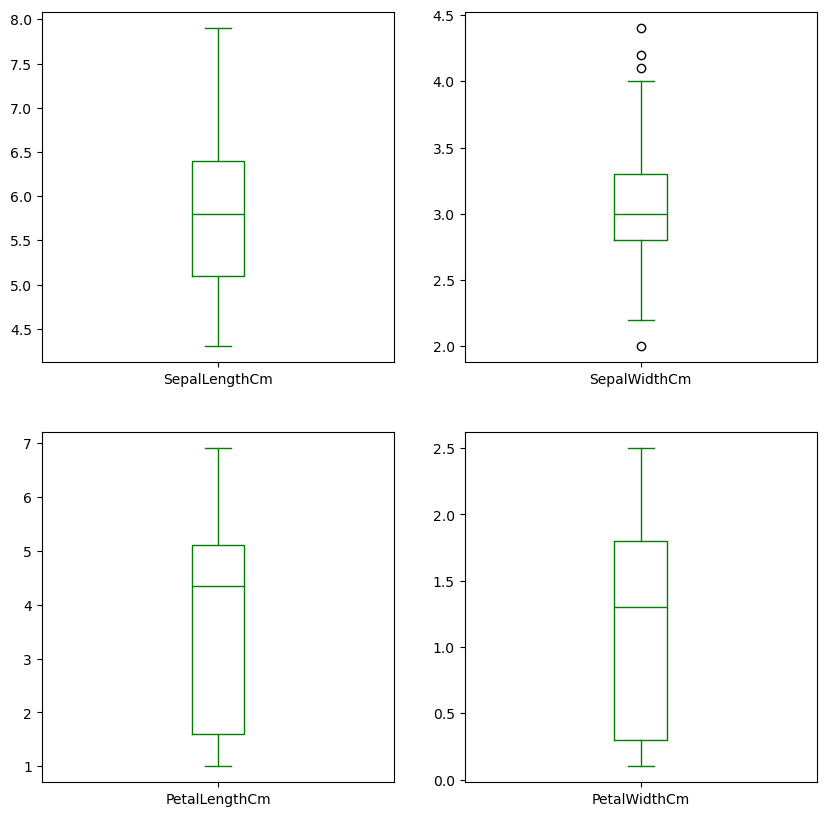

In [36]:
import matplotlib.pyplot as plt 

# box and whisker plots
dataset.plot(kind='box', subplots=True, layout=(2,2), sharex=False, sharey=False,color="green", figsize=(10,10))
plt.show()

<Axes: >

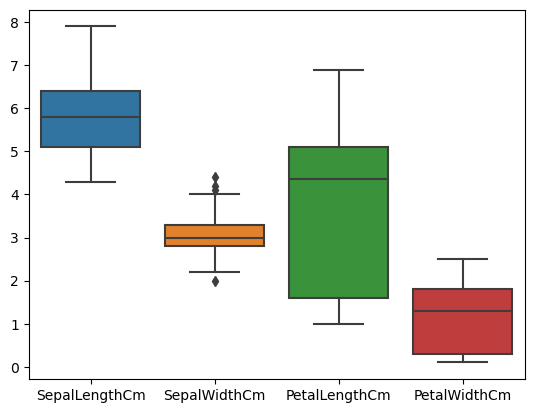

In [37]:
import seaborn as sns 

sns.boxplot(data=dataset)

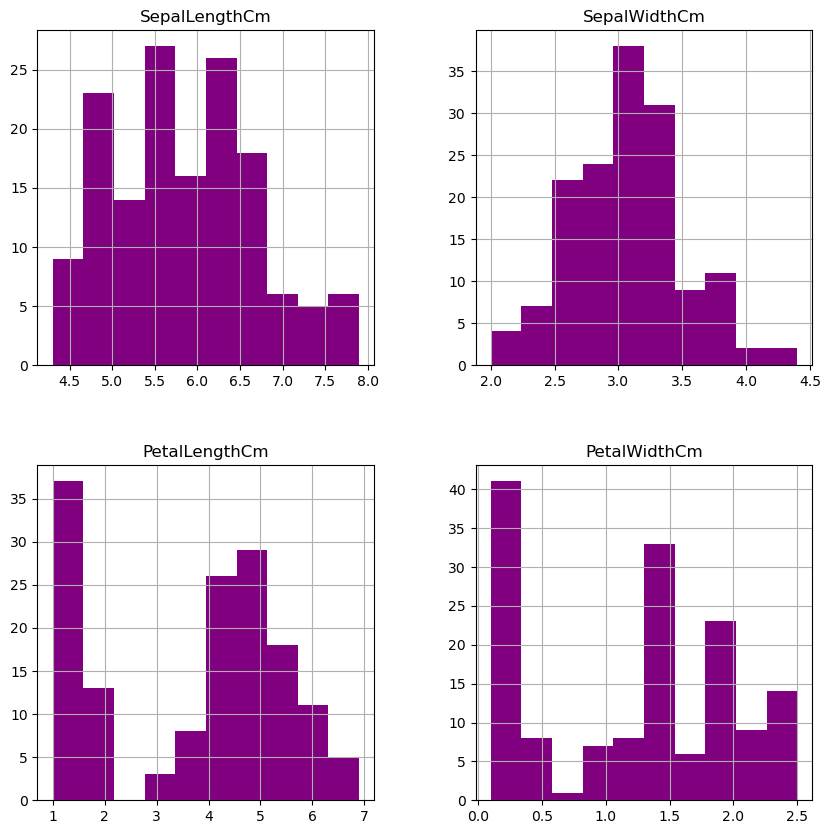

In [38]:
# histograms
dataset.hist(color="purple",figsize=(10,10))
plt.show()

##### Multivariate plots

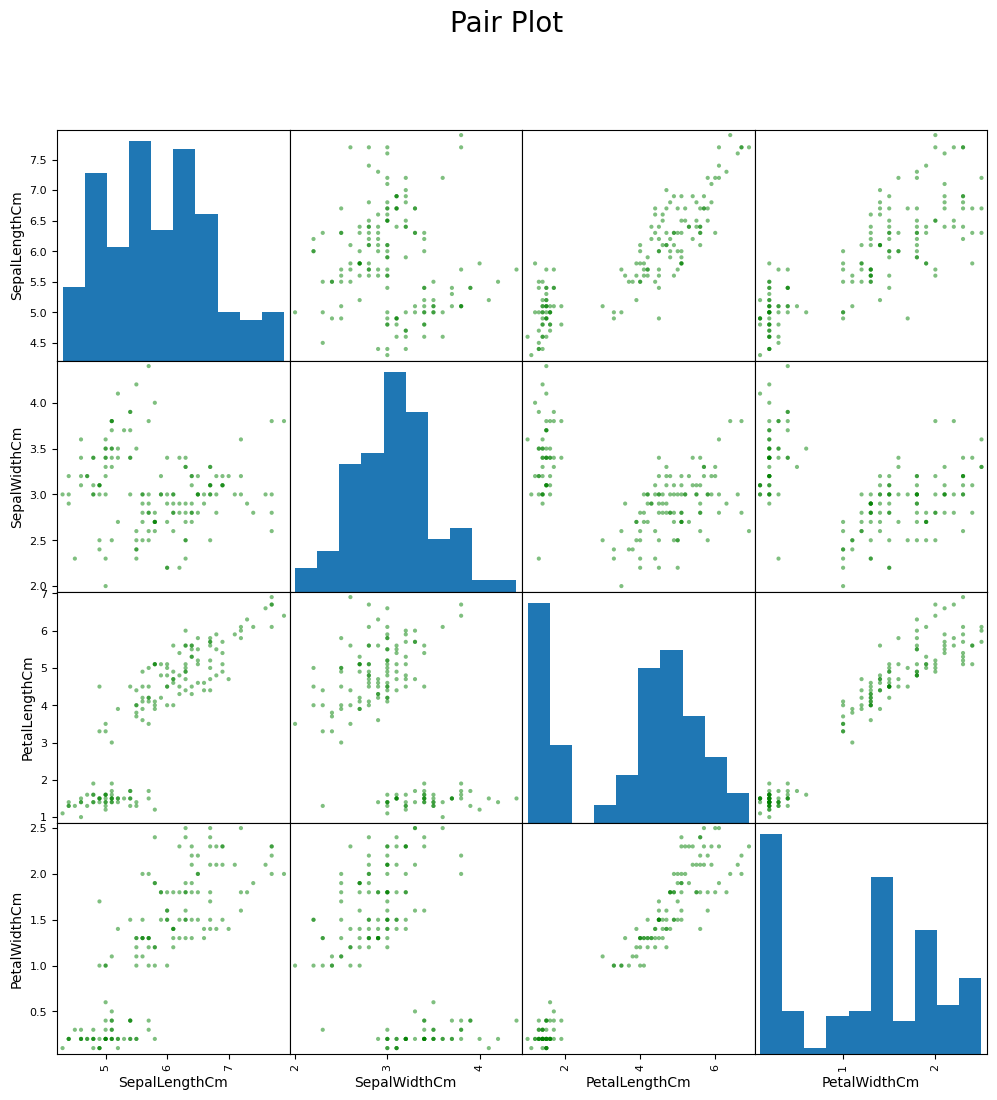

In [39]:
from pandas.plotting import scatter_matrix

# Scatter plot matrix
scatter_matrix(dataset,color="green",figsize =(12,12))
# Use suptitle to add title to all sublots
plt.suptitle("Pair Plot", fontsize=20)
plt.show()

c:\Users\Han\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Han\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Han\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Han\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 li

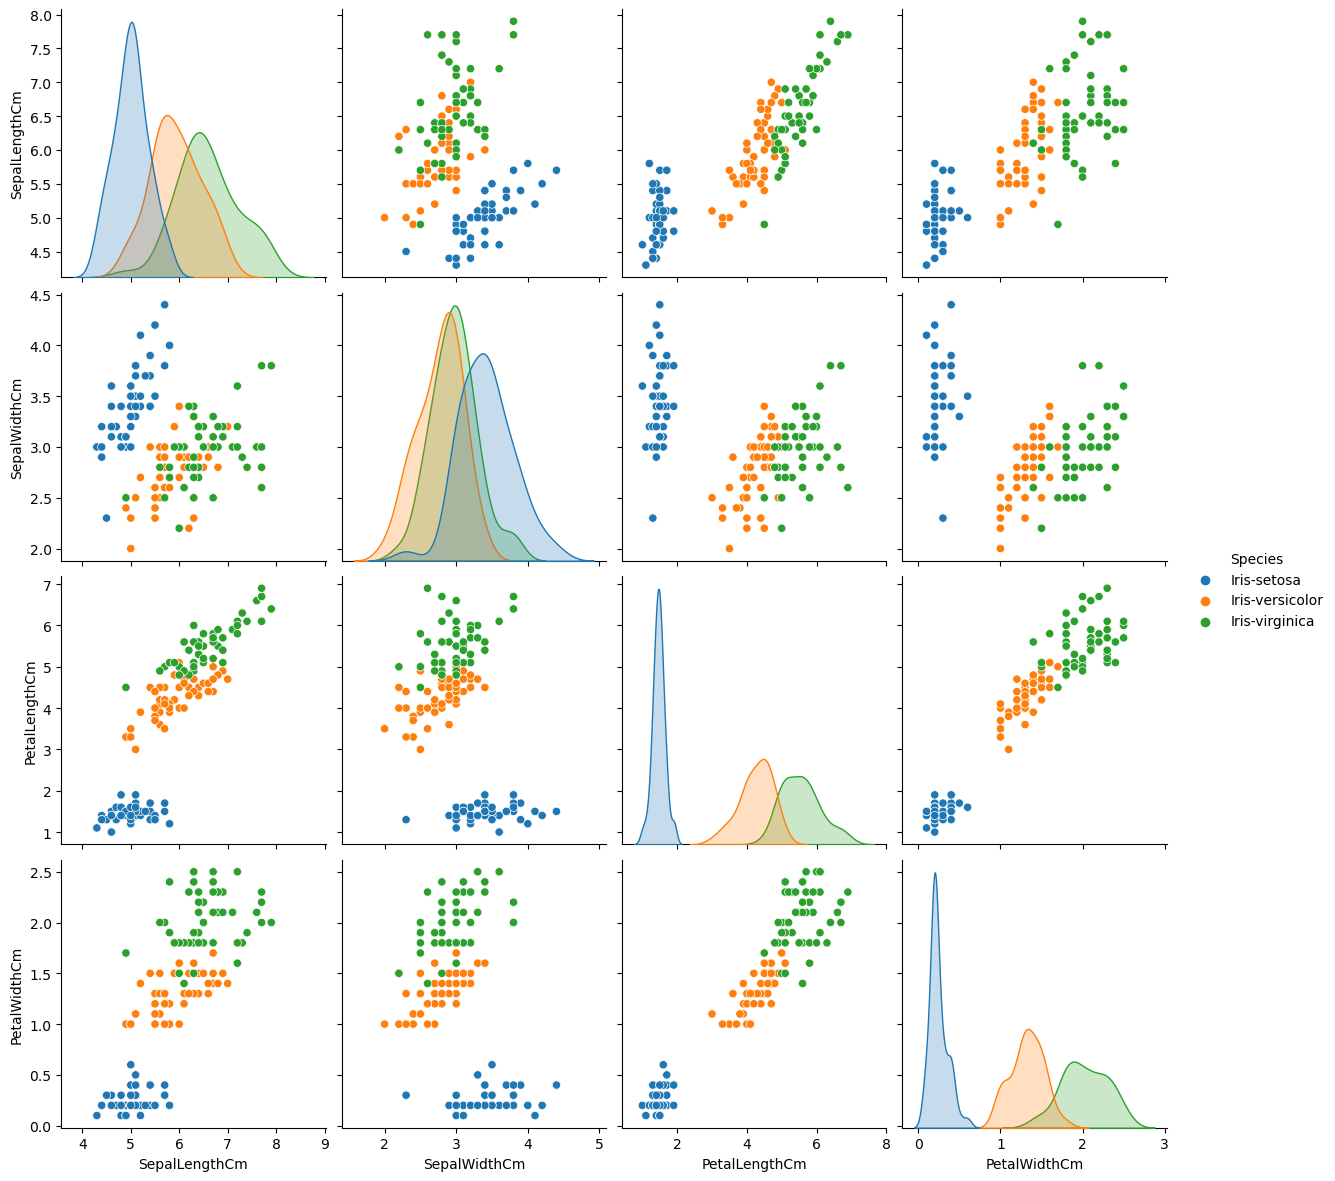

In [40]:
# Using seaboarns package we can show rich plots
sns.pairplot(dataset, hue="Species", height=3, diag_kind="kde")
plt.show()

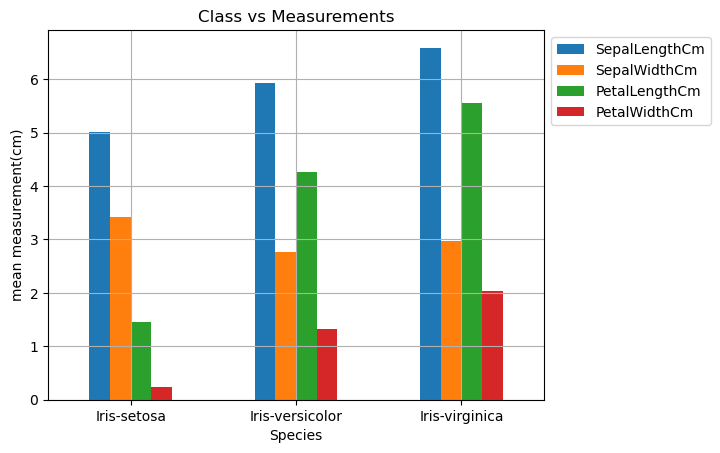

In [41]:
# print the mean for each column by species
dataset.groupby(by = "Species").mean()
# plot for mean of each feature for each label class
dataset.groupby(by = "Species").mean().plot(kind="bar")
plt.title('Class vs Measurements')
plt.ylabel('mean measurement(cm)')
plt.xticks(rotation=0)  # manage the xticks rotation
plt.grid(True)
# Use bbox_to_anchor option to place the legend outside plot area to be tidy
plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.show()

               SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
SepalLengthCm       1.000000     -0.109369       0.871754      0.817954
SepalWidthCm       -0.109369      1.000000      -0.420516     -0.356544
PetalLengthCm       0.871754     -0.420516       1.000000      0.962757
PetalWidthCm        0.817954     -0.356544       0.962757      1.000000


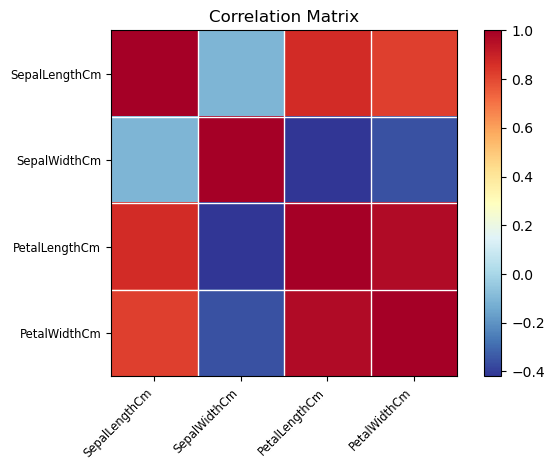

In [42]:
import statsmodels.api as sm

# create correlation matrix
corr = dataset.corr(numeric_only=True)
print(corr)

sm.graphics.plot_corr(corr, xnames=list(corr.columns))
plt.show()

#### Convert target variable (Species) as category

In [43]:
# Convert target variable (Species) as category
dataset.Species = dataset.Species.astype('category')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   SepalLengthCm  150 non-null    float64 
 1   SepalWidthCm   150 non-null    float64 
 2   PetalLengthCm  150 non-null    float64 
 3   PetalWidthCm   150 non-null    float64 
 4   Species        150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


In [44]:
dataset.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [45]:
# Access converted values using codes property
dataset.Species.cat.codes.unique()

array([0, 1, 2], dtype=int8)

In [46]:
dataset.Species.unique()

['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Categories (3, object): ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

In [47]:
# Placing converted values to Species column
dataset.Species = dataset.Species.cat.codes

dataset

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [48]:
# Perform one-hot encoding on the species column of the Iris dataset
one_hot_dataset = pd.get_dummies(dataset, columns=['Species'])

one_hot_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species_0      150 non-null    bool   
 5   Species_1      150 non-null    bool   
 6   Species_2      150 non-null    bool   
dtypes: bool(3), float64(4)
memory usage: 5.3 KB


In [49]:
# Standardise the length and width columns of the iris dataset

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
dataset[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']] = scaler.fit_transform(dataset[
    ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']])

In [50]:
dataset

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,-0.900681,1.032057,-1.341272,-1.312977,0
1,-1.143017,-0.124958,-1.341272,-1.312977,0
2,-1.385353,0.337848,-1.398138,-1.312977,0
3,-1.506521,0.106445,-1.284407,-1.312977,0
4,-1.021849,1.263460,-1.341272,-1.312977,0
...,...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956,2
146,0.553333,-1.281972,0.705893,0.922064,2
147,0.795669,-0.124958,0.819624,1.053537,2
148,0.432165,0.800654,0.933356,1.447956,2


#### Now we have a clean dataset with standardised features

In [51]:
# Create two new columns: sepal_ratio and petal_ratio
dataset['SepalRatio'] = dataset['SepalLengthCm'] / dataset['SepalWidthCm']
dataset['PetalRatio'] = dataset['PetalLengthCm'] / dataset['PetalWidthCm']
dataset

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,SepalRatio,PetalRatio
0,-0.900681,1.032057,-1.341272,-1.312977,0,-0.872705,1.021551
1,-1.143017,-0.124958,-1.341272,-1.312977,0,9.147238,1.021551
2,-1.385353,0.337848,-1.398138,-1.312977,0,-4.100517,1.064861
3,-1.506521,0.106445,-1.284407,-1.312977,0,-14.152993,0.978240
4,-1.021849,1.263460,-1.341272,-1.312977,0,-0.808770,1.021551
...,...,...,...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956,2,-8.306856,0.566056
146,0.553333,-1.281972,0.705893,0.922064,2,-0.431627,0.765558
147,0.795669,-0.124958,0.819624,1.053537,2,-6.367512,0.777974
148,0.432165,0.800654,0.933356,1.447956,2,0.539765,0.644602
